# **Requirement 3: Single/Multi Campaign and Highly Non-Stationary Environment**

We again model online ad bidding, but now the market is **adversarial / highly
non-stationary**: the highest competing bid for each campaign is a *deterministic
sequence* whose statistics change quickly over time, instead of i.i.d. draws from
a fixed distribution.

At each round $t$, for every campaign $i$ the advertiser:
1. Submits a **bid** $b_{t,i}$ from a discrete bid set $\mathcal{B}=\{b^{(1)},\dots,b^{(K)}\}$ (arms).
2. Wins if $b_{t,i}\ge m_{t,i}$, where $m_{t,i}$ is the **highest competing bid** for campaign $i$ at round $t$.
3. On a win (first price) it pays $m_{t,i}\le b_{t,i}$ &mdash; here, as in Req. 1/2, the environment charges the bid; reward is $f_{t,i}=(v_i-b_{t,i})\,\mathbf{1}[b_{t,i}\ge m_{t,i}]$ and cost is $c_{t,i}=b_{t,i}\,\mathbf{1}[b_{t,i}\ge m_{t,i}]$.

All campaigns share a **single budget** $B$ over the horizon $T$.

**What is new w.r.t. Requirement 1**
- The environment is **non-stochastic / highly non-stationary**: $\{m_{t,i}\}_t$ is sampled from a Beta distribution whose parameters drift continuously with $t$, so there is no fixed $F$ to learn.
- The algorithm is a **primal-dual** method with a budget constraint. The hint is to design a **primal regret minimizer** for the problem; with **full feedback** (we observe $m_{t,i}$ for *every* auction, won or not) the natural primal minimizer is **Hedge** (exponential weights) &mdash; no exploration is needed.
- A single **dual variable** $\lambda_t$ paces spending against the shared budget.

The benchmark is therefore not a fixed-distribution OPT but the **best fixed
bidding policy in claivoyant** that respects the budget &mdash; exactly what a primal
regret minimizer competes against.


In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

# Make the Requirement-3 environment / learner importable. The notebook lives at
# the project root; the modules live in src/req3.
for p in ['src/req3', os.path.abspath('src/req3'),
          os.path.abspath(os.path.join('..', 'src', 'req3'))]:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.append(p)

from environments_req3 import (
    FullFeedbackMultiCampaignEnvironment,
    make_nonstationary_beta_dist,
)
from learners_req3 import PrimalDualMultiCampaignAgent

---
## Part 1: Build a Highly Non-Stationary Environment

The environment is `FullFeedbackMultiCampaignEnvironment`. It is driven by a
*joint* sequence of highest competing bids $m\in\mathbb{R}^{T\times N}$ produced by
`make_nonstationary_beta_dist(N, schedule, seed)`, where

$$m_{t,i}\sim \mathrm{Beta}\big(a(t,i),\,b(t,i)\big).$$

The **non-stationarity lives entirely in the `schedule(t, i) -> (a, b)`**: by making
$(a,b)$ change quickly with $t$ we obtain a market whose competition level swings
rapidly over time. We design two regimes:

- **Regime-switching (piecewise-constant, fast switches)** &mdash; every $L$ rounds the
  competition for each campaign jumps to a new Beta profile (low / high / symmetric /
  aggressive). This is the *highly non-stationary* market we run the algorithm on.
- **Sinusoidal drift** &mdash; the mean competing bid oscillates smoothly, a milder
  non-stationarity shown for comparison.

`Beta(a,b)` has mean $a/(a+b)$, so plotting that over time visualises how the
market moves.


In [2]:
# --- Global problem configuration ---
N = 3                                   # number of campaigns (shares one budget)
values = np.array([1.0, 0.8, 1.2])      # per-campaign valuations v_i
K = 11
bid_space = np.linspace(0.0, 1.0, K)    # shared discrete bid set (arm 0 = abstain)
no_conflict = np.zeros((N, N), dtype=bool)   # Req.3: campaigns independent, only the budget couples them

def make_linear_drift_schedule(T, mean_start=0.2, mean_end=0.8, conc=8.0):
    '''Beta parameters whose mean drifts linearly with t, from mean_start to
    mean_end over the horizon [0, T]. This is the only source of
    non-stationarity: no periodicity, no regime jumps -- (a, b) is a direct,
    deterministic, monotonic function of t. A small per-campaign phase shift
    (+i) keeps the campaigns from being perfectly synchronised.'''
    def schedule(t, i):
        frac = min(max((t + i) / T, 0.0), 1.0)
        mean = mean_start + frac * (mean_end - mean_start)
        a = mean * conc
        b = (1.0 - mean) * conc
        return a, b
    return schedule


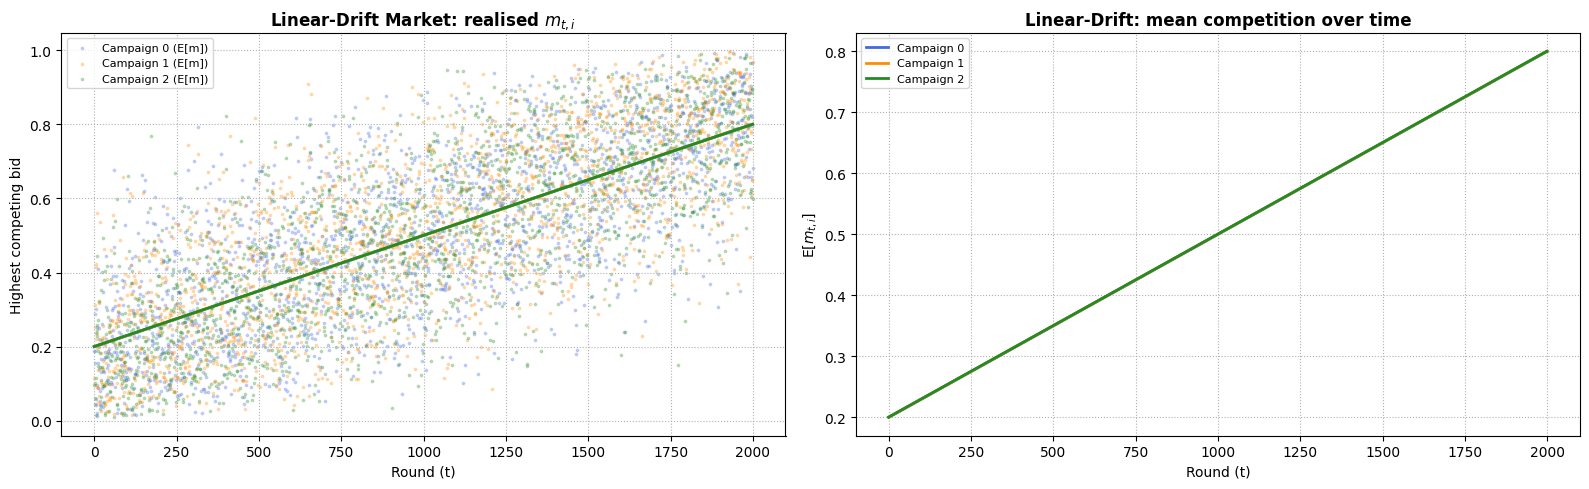

In [3]:
# Visualise the linear-drift non-stationary market for a representative horizon.
T_vis = 2000
drift_schedule = make_linear_drift_schedule(T_vis)
jd_drift = make_nonstationary_beta_dist(N, drift_schedule, seed=7)

m_drift = jd_drift(size=T_vis)   # (T_vis, N)

# Theoretical instantaneous mean a/(a+b) for each campaign
mean_drift = np.array([[ (lambda ab: ab[0]/(ab[0]+ab[1]))(drift_schedule(t, i))
                         for i in range(N)] for t in range(T_vis)])

colors = ['royalblue', 'darkorange', 'forestgreen']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(N):
    axes[0].scatter(range(T_vis), m_drift[:, i], s=3, alpha=0.25, color=colors[i],
                    label=f'Campaign {i} (E[m])')
    axes[0].plot(range(T_vis), mean_drift[:, i], color=colors[i], lw=2)
axes[0].set_title('Linear-Drift Market: realised $m_{t,i}$', fontweight='bold')
axes[0].set_xlabel('Round (t)'); axes[0].set_ylabel('Highest competing bid')
axes[0].legend(loc='upper left', fontsize=8); axes[0].grid(True, linestyle=':')

for i in range(N):
    axes[1].plot(range(T_vis), mean_drift[:, i], color=colors[i], lw=2,
                 label=f'Campaign {i}')
axes[1].set_title('Linear-Drift: mean competition over time', fontweight='bold')
axes[1].set_xlabel('Round (t)'); axes[1].set_ylabel('E[$m_{t,i}$]')
axes[1].legend(loc='upper left', fontsize=8); axes[1].grid(True, linestyle=':')

plt.tight_layout(); plt.show()


---
## Part 2: The Primal-Dual Bidding Algorithm

`PrimalDualMultiCampaignAgent` implements a primal-dual scheme with one shared
budget across the $N$ campaigns.


In [ ]:
def run_primal_dual(T, B, schedule, seed, values=values, bid_space=bid_space,
                    conflict=no_conflict, eta=None):
    '''Run the primal-dual agent for one trajectory. Returns per-round series.'''
    N = len(values)
    jd = make_nonstationary_beta_dist(N, schedule, seed=seed)
    env = FullFeedbackMultiCampaignEnvironment(values, T, jd, conflict)
    agent = PrimalDualMultiCampaignAgent(values, bid_space, B, T, eta=eta)

    util = np.zeros(T); cost = np.zeros(T); lam = np.zeros(T)
    bids = np.zeros((T, N))
    for t in range(T):
        idx = agent.bid()
        b_vec = bid_space[idx]
        won, rew, c, m_t = env.resolve_auction(b_vec)
        agent.update(won, rew, c, m_t)
        util[t] = rew.sum(); cost[t] = c.sum(); lam[t] = agent.lmbd
        bids[t] = b_vec
    return dict(util=util, cost=cost, lam=lam, bids=bids,
                m_seq=env.get_m_sequence())


def claivoyant_opt(m_seq, values, bid_space, rho):
    '''Best fixed budget-feasible bidding policy in claivoyant (per-round OPT).

    Finds the best mixed strategy you *could* have committed to for the whole
    horizon, knowing the realised competing-bid sequence in advance.

    For each campaign i it picks a probability distribution gamma_i over bids.
    The chosen distributions must:
        - maximise total expected per-round utility across all campaigns
        - respect ONE shared per-round budget rho (= B / T)
        - each be a valid probability distribution (sums to 1)

    Returns: (opt_value, gamma, f, c)
        opt_value : best achievable utility per round (the OPT benchmark)
        gamma     : (N, K) optimal bid distribution per campaign
        f, c      : (N, K) claivoyant average reward / cost of each bid
    '''
    T = m_seq.shape[0]          # number of rounds
    N = len(values)             # number of campaigns
    K = len(bid_space)          # number of candidate bids

    # ------------------------------------------------------------------
    # Step 1: For every campaign and every bid, compute the claivoyant
    #         average reward (f) and average cost (c) over all T rounds.
    #
    #   A bid k WINS round t (for campaign i) if  bid_k >= m_seq[t, i].
    #   When it wins:  reward = value_i - bid_k ,  cost = bid_k
    #   When it loses: reward = 0             ,  cost = 0
    # ------------------------------------------------------------------
    f = np.zeros((N, K))        # f[i, k] = avg reward of bid k on campaign i
    c = np.zeros((N, K))        # c[i, k] = avg cost   of bid k on campaign i

    for i in range(N):
        for k in range(K):
            bid_k = bid_space[k]

            # Did this bid win, in each of the T rounds? -> boolean array (T,)
            wins = bid_k >= m_seq[:, i]

            # Average reward and cost across all rounds (losses contribute 0).
            f[i, k] = np.mean((values[i] - bid_k) * wins)
            c[i, k] = np.mean(bid_k * wins)

    # ------------------------------------------------------------------
    # Step 2: Set up the Linear Program.
    #
    # Decision variables: gamma[i, k]  (flattened into one long vector of
    # length N*K, ordered campaign-by-campaign).
    #
    #   maximise   sum_{i,k} gamma[i,k] * f[i,k]
    #   subject to:
    #     (a) shared budget : sum_{i,k} gamma[i,k] * c[i,k] <= rho
    #     (b) simplex       : sum_k gamma[i,k] == 1   for every campaign i
    #     (c) bounds        : 0 <= gamma[i,k] <= 1
    # ------------------------------------------------------------------

    # Objective. linprog MINIMISES, so we negate to turn max into min.
    objective = -f.flatten()                     # length N*K

    # (a) One inequality row: the single shared budget constraint.
    A_budget = c.flatten().reshape(1, -1)        # shape (1, N*K)
    b_budget = [rho]

    # (b) N equality rows: one per campaign, forcing its bids to sum to 1.
    #     Row i has 1s only in the K columns that belong to campaign i.
    A_simplex = np.zeros((N, N * K))
    for i in range(N):
        start = i * K
        end = start + K
        A_simplex[i, start:end] = 1.0
    b_simplex = np.ones(N)

    # (c) Each gamma is a probability, so it lives in [0, 1].
    bounds = [(0, 1)] * (N * K)

    # ------------------------------------------------------------------
    # Step 3: Solve and unpack.
    # ------------------------------------------------------------------
    res = linprog(
        c=objective,
        A_ub=A_budget, b_ub=b_budget,
        A_eq=A_simplex, b_eq=b_simplex,
        bounds=bounds,
        method='highs',
    )

    gamma = res.x.reshape(N, K)   # back to (N, K) layout
    opt_value = -res.fun          # undo the earlier negation -> max utility

    return opt_value, gamma, f, c

---
## Part 3: Single Trajectory (Binding Budget)

We run one trajectory on the **highly non-stationary regime-switching market** with
a *binding* budget $B = 0.5\,T$ (the agent cannot afford to win every auction it
would like to). We track utility, spend, the dual variable $\lambda_t$, and the
bids actually played, and compare against the claivoyant budget-feasible OPT.


In [ ]:
T = 5000
B = 0.5 * T
rho = B / T

np.random.seed(42)
drift_schedule = make_linear_drift_schedule(T)
run = run_primal_dual(T, B, drift_schedule, seed=123)

OPT, gamma, f_hat, c_hat = claivoyant_opt(run['m_seq'], values, bid_space, rho)

time_steps = np.arange(1, T + 1)
cum_util = np.cumsum(run['util'])
cum_cost = np.cumsum(run['cost'])
baseline = time_steps * OPT
regret = baseline - cum_util

print(f"claivoyant budget-feasible OPT : {OPT:.4f} / round  ({OPT*T:.1f} cumulative)")
print(f"Agent cumulative utility      : {cum_util[-1]:.1f}")
print(f"Total spend / budget          : {cum_cost[-1]:.1f} / {B:.0f}")
print(f"Terminal regret               : {regret[-1]:.1f}  ({regret[-1]/T:.4f} per round)")


Hindsight budget-feasible OPT : 0.6971 / round  (3485.5 cumulative)
Agent cumulative utility      : 2137.3
Total spend / budget          : 1304.1 / 2500
Terminal regret               : 1348.2  (0.2696 per round)


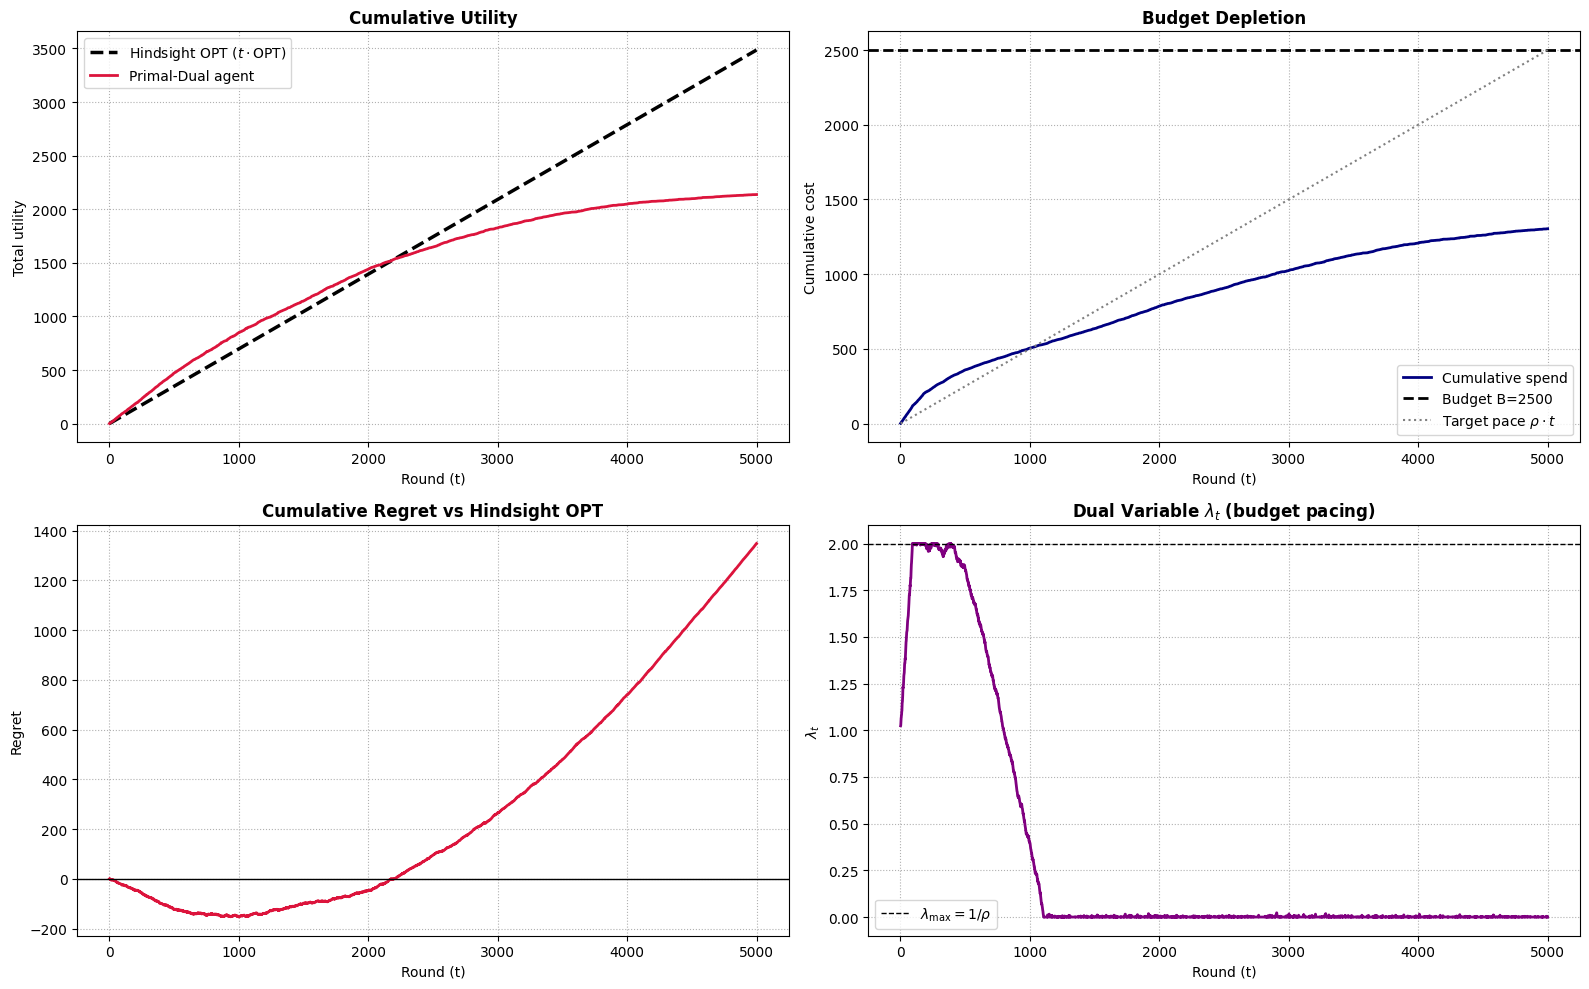

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cumulative utility vs fluid baseline
axes[0, 0].plot(time_steps, baseline, color='black', lw=2.5, linestyle='--',
                label=r'claivoyant OPT ($t\cdot$OPT)')
axes[0, 0].plot(time_steps, cum_util, color='crimson', lw=2, label='Primal-Dual agent')
axes[0, 0].set_title('Cumulative Utility', fontweight='bold')
axes[0, 0].set_xlabel('Round (t)'); axes[0, 0].set_ylabel('Total utility')
axes[0, 0].grid(True, linestyle=':'); axes[0, 0].legend()

# Budget depletion
axes[0, 1].plot(time_steps, cum_cost, color='navy', lw=2, label='Cumulative spend')
axes[0, 1].axhline(B, color='black', lw=2, linestyle='--', label=f'Budget B={B:.0f}')
axes[0, 1].plot(time_steps, rho * time_steps, color='grey', lw=1.5, linestyle=':',
                label=r'Target pace $\rho\cdot t$')
axes[0, 1].set_title('Budget Depletion', fontweight='bold')
axes[0, 1].set_xlabel('Round (t)'); axes[0, 1].set_ylabel('Cumulative cost')
axes[0, 1].grid(True, linestyle=':'); axes[0, 1].legend()

# Regret
axes[1, 0].plot(time_steps, regret, color='crimson', lw=2)
axes[1, 0].axhline(0, color='black', lw=1)
axes[1, 0].set_title('Cumulative Regret vs claivoyant OPT', fontweight='bold')
axes[1, 0].set_xlabel('Round (t)'); axes[1, 0].set_ylabel('Regret')
axes[1, 0].grid(True, linestyle=':')

# Dual variable
axes[1, 1].plot(time_steps, run['lam'], color='purple', lw=2)
axes[1, 1].axhline(1.0 / rho, color='black', lw=1, linestyle='--', label=r'$\lambda_{\max}=1/\rho$')
axes[1, 1].set_title(r'Dual Variable $\lambda_t$ (budget pacing)', fontweight='bold')
axes[1, 1].set_xlabel('Round (t)'); axes[1, 1].set_ylabel(r'$\lambda_t$')
axes[1, 1].grid(True, linestyle=':'); axes[1, 1].legend()

plt.tight_layout(); plt.show()

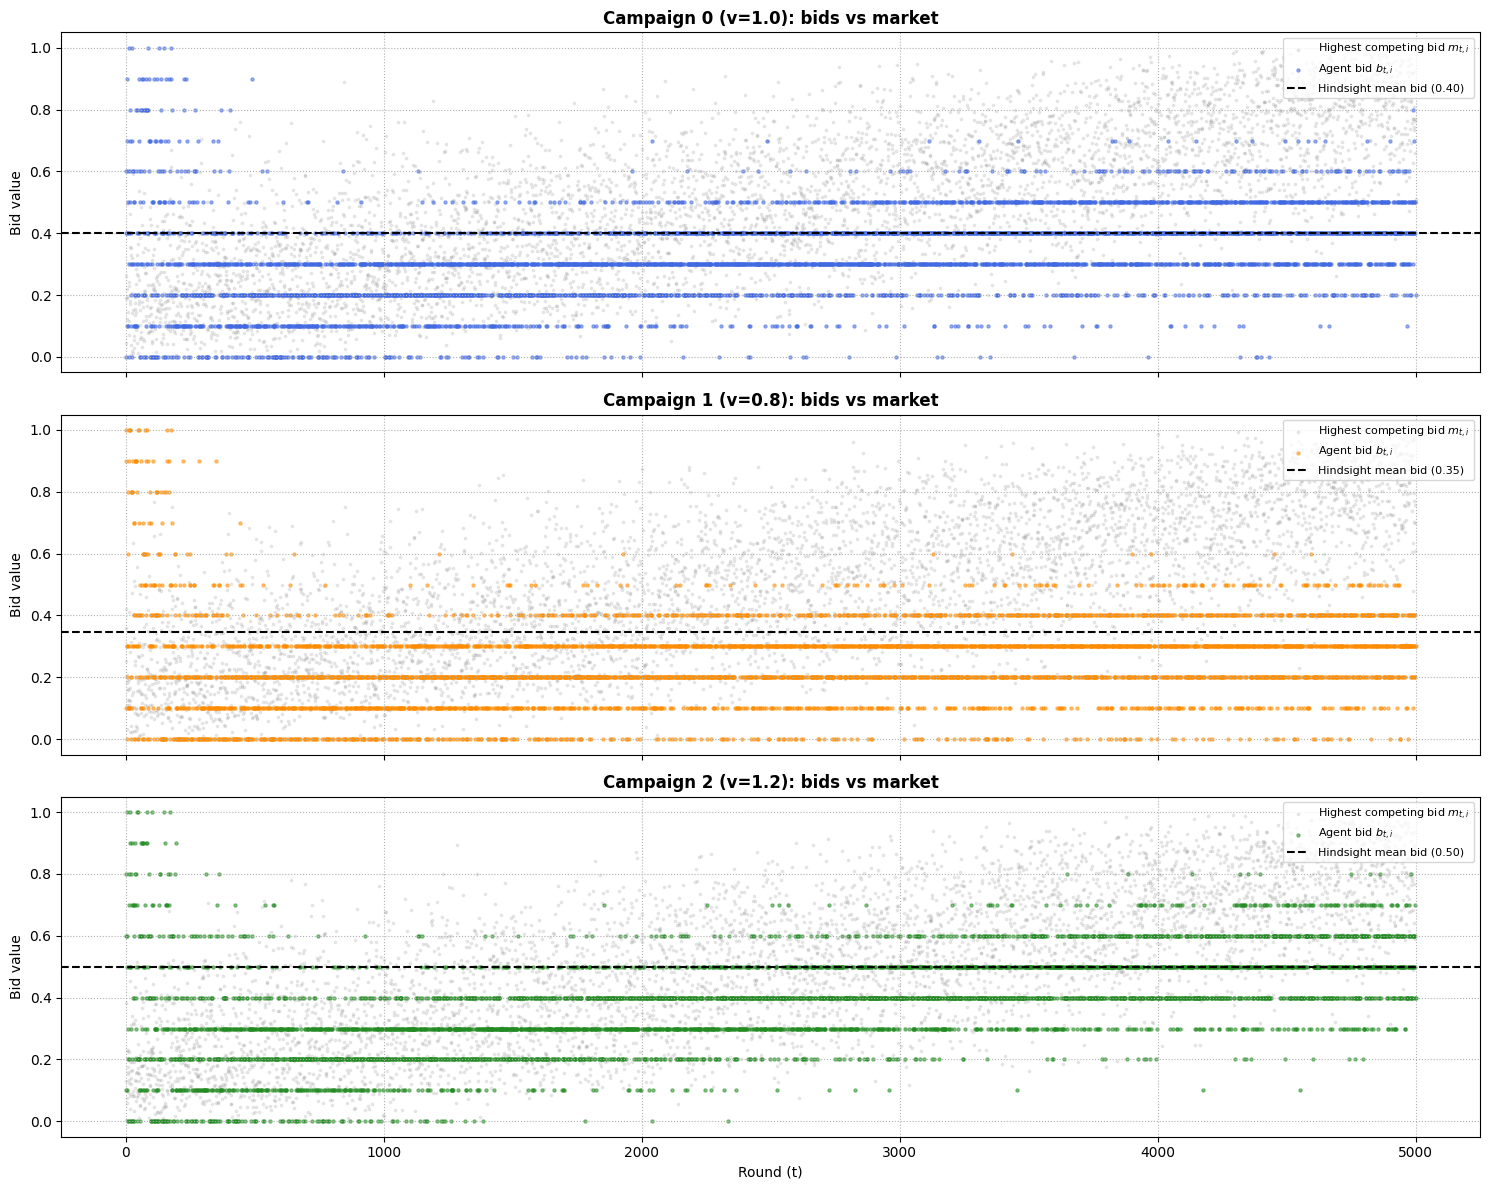

In [ ]:
# How the agent's bids track the moving market, per campaign.
fig, axes = plt.subplots(N, 1, figsize=(15, 4 * N), sharex=True)
for i in range(N):
    ax = axes[i]
    ax.scatter(time_steps, run['m_seq'][:, i], s=3, alpha=0.15, color='grey',
               label='Highest competing bid $m_{t,i}$')
    ax.scatter(time_steps, run['bids'][:, i], s=5, alpha=0.5, color=colors[i],
               label='Agent bid $b_{t,i}$')
    # claivoyant mixed bid (expected bid under the OPT distribution) as a reference
    opt_bid_i = np.sum(gamma[i] * bid_space)
    ax.axhline(opt_bid_i, color='black', lw=1.5, linestyle='--',
               label=f'claivoyant mean bid ({opt_bid_i:.2f})')
    ax.set_title(f'Campaign {i} (v={values[i]}): bids vs market', fontweight='bold')
    ax.set_ylabel('Bid value'); ax.grid(True, linestyle=':')
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Round (t)')
plt.tight_layout(); plt.show()

---
## Part 4: Several Trajectories (Monte Carlo)

A single run is noisy because the market sequence is random per seed. We repeat the
experiment over many independent non-stationary sequences and report mean $\pm$ std
of the regret and of the cumulative spend. Each trajectory recomputes its own
claivoyant OPT (the benchmark is sequence-specific).


Executing Monte Carlo: N=20, T=5000, B=2500
  simulation 0/20...


  simulation 5/20...


  simulation 10/20...


  simulation 15/20...


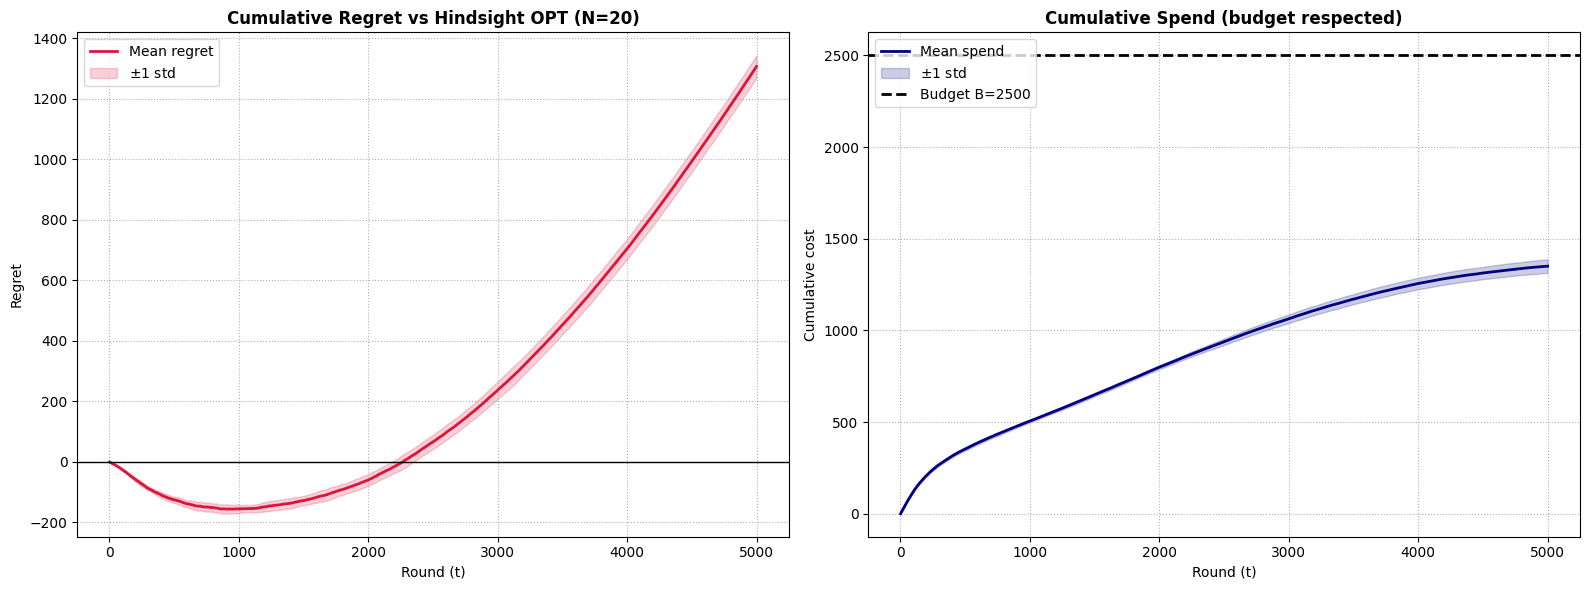


Mean terminal regret      : 1307.4  (0.2615 / round)
Mean terminal spend       : 1350.6 / 2500
Budget violations (> B)   : 0/20


In [ ]:
N_SIMULATIONS = 20
T = 5000
B = 0.5 * T
rho = B / T
time_steps = np.arange(1, T + 1)
drift_schedule = make_linear_drift_schedule(T)

regret_mat = np.zeros((N_SIMULATIONS, T))
cost_mat   = np.zeros((N_SIMULATIONS, T))
opt_vals   = np.zeros(N_SIMULATIONS)

print(f"Executing Monte Carlo: N={N_SIMULATIONS}, T={T}, B={B:.0f}")
for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"  simulation {sim}/{N_SIMULATIONS}...")
    r = run_primal_dual(T, B, drift_schedule, seed=1000 + sim)
    OPT_s, _, _, _ = claivoyant_opt(r['m_seq'], values, bid_space, rho)
    opt_vals[sim] = OPT_s
    regret_mat[sim] = time_steps * OPT_s - np.cumsum(r['util'])
    cost_mat[sim]   = np.cumsum(r['cost'])

mean_reg, std_reg = regret_mat.mean(0), regret_mat.std(0)
mean_cost, std_cost = cost_mat.mean(0), cost_mat.std(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(time_steps, mean_reg, color='crimson', lw=2, label='Mean regret')
axes[0].fill_between(time_steps, mean_reg - std_reg, mean_reg + std_reg,
                     color='crimson', alpha=0.2, label=r'$\pm 1$ std')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title(f'Cumulative Regret vs claivoyant OPT (N={N_SIMULATIONS})', fontweight='bold')
axes[0].set_xlabel('Round (t)'); axes[0].set_ylabel('Regret')
axes[0].grid(True, linestyle=':'); axes[0].legend(loc='upper left')

axes[1].plot(time_steps, mean_cost, color='navy', lw=2, label='Mean spend')
axes[1].fill_between(time_steps, mean_cost - std_cost, mean_cost + std_cost,
                     color='navy', alpha=0.2, label=r'$\pm 1$ std')
axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f'Budget B={B:.0f}')
axes[1].set_title('Cumulative Spend (budget respected)', fontweight='bold')
axes[1].set_xlabel('Round (t)'); axes[1].set_ylabel('Cumulative cost')
axes[1].grid(True, linestyle=':'); axes[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f"\nMean terminal regret      : {mean_reg[-1]:.1f}  ({mean_reg[-1]/T:.4f} / round)")
print(f"Mean terminal spend       : {mean_cost[-1]:.1f} / {B:.0f}")
print(f"Budget violations (> B)   : {int((cost_mat[:, -1] > B + 1e-6).sum())}/{N_SIMULATIONS}")


---
## Part 5: Effect of the Budget &mdash; Non-binding vs Binding

As in Requirement 1 we contrast a **non-binding** budget ($B=T$, the agent can win
essentially everything it wants) with **binding** budgets ($B=0.5\,T$, $B=0.3\,T$).
A binding budget drives the dual variable $\lambda_t$ to a persistently **positive**
level (vs. $\approx 0$ when non-binding), which lowers the spend and raises the
regret &mdash; while spend always stays under $B$. (Under a very tight budget the
agent exhausts $B$ before the horizon and freezes $\lambda_t$, so its final value
need not increase monotonically with tightness.)


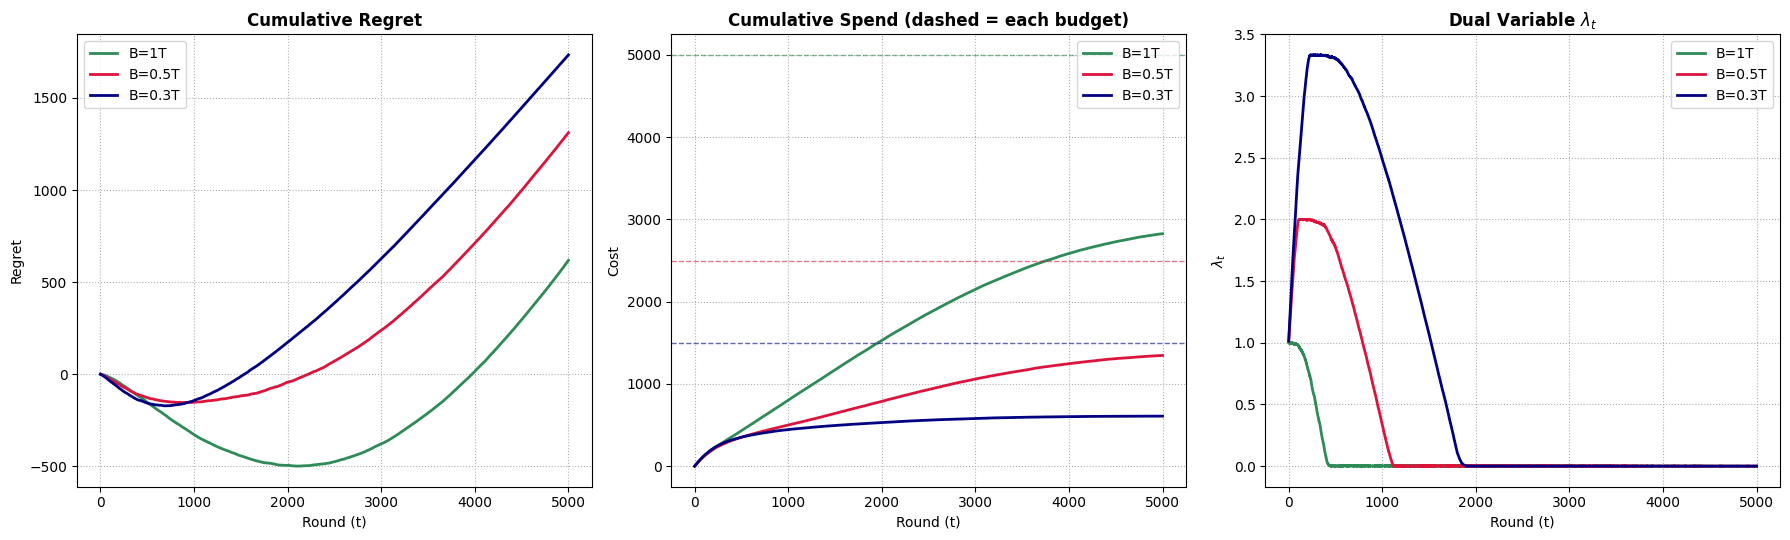

  Budget |     Regret |      Spend | final lambda
     1T |      618.4 |     2826.3 |        0.000
   0.5T |     1311.7 |     1346.9 |        0.000
   0.3T |     1734.1 |      609.5 |        0.000


In [ ]:
budget_fracs = [1.0, 0.5, 0.3]
T = 5000
N_SIM = 10
time_steps = np.arange(1, T + 1)
drift_schedule = make_linear_drift_schedule(T)

summary = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
palette = {1.0: 'seagreen', 0.5: 'crimson', 0.3: 'navy'}

for frac in budget_fracs:
    B = frac * T; rho = B / T
    reg = np.zeros((N_SIM, T)); cst = np.zeros((N_SIM, T)); lams = np.zeros((N_SIM, T))
    for sim in range(N_SIM):
        r = run_primal_dual(T, B, drift_schedule, seed=2000 + sim)
        OPT_s, _, _, _ = claivoyant_opt(r['m_seq'], values, bid_space, rho)
        reg[sim] = time_steps * OPT_s - np.cumsum(r['util'])
        cst[sim] = np.cumsum(r['cost']); lams[sim] = r['lam']
    mreg, mcst, mlam = reg.mean(0), cst.mean(0), lams.mean(0)
    summary[frac] = (mreg[-1], mcst[-1], mlam[-1])

    axes[0].plot(time_steps, mreg, color=palette[frac], lw=2, label=f'B={frac:g}T')
    axes[1].plot(time_steps, mcst, color=palette[frac], lw=2, label=f'B={frac:g}T')
    axes[1].axhline(B, color=palette[frac], lw=1, linestyle='--', alpha=0.6)
    axes[2].plot(time_steps, mlam, color=palette[frac], lw=2, label=f'B={frac:g}T')

axes[0].set_title('Cumulative Regret', fontweight='bold')
axes[0].set_xlabel('Round (t)'); axes[0].set_ylabel('Regret')
axes[0].grid(True, linestyle=':'); axes[0].legend()
axes[1].set_title('Cumulative Spend (dashed = each budget)', fontweight='bold')
axes[1].set_xlabel('Round (t)'); axes[1].set_ylabel('Cost')
axes[1].grid(True, linestyle=':'); axes[1].legend()
axes[2].set_title(r'Dual Variable $\lambda_t$', fontweight='bold')
axes[2].set_xlabel('Round (t)'); axes[2].set_ylabel(r'$\lambda_t$')
axes[2].grid(True, linestyle=':'); axes[2].legend()
plt.tight_layout(); plt.show()

print(f"{'Budget':>8} | {'Regret':>10} | {'Spend':>10} | {'final lambda':>12}")
for frac in budget_fracs:
    mreg, mcst, mlam = summary[frac]
    print(f"{frac:>6g}T | {mreg:>10.1f} | {mcst:>10.1f} | {mlam:>12.3f}")


---
## Part 6: Regret is Sublinear in the Horizon

A regret minimizer must have $R_T/T \to 0$. We run the binding-budget setup
($B=0.5\,T$) for growing horizons and confirm the **per-round** regret shrinks,
i.e. cumulative regret grows sublinearly even though the market is highly
non-stationary.


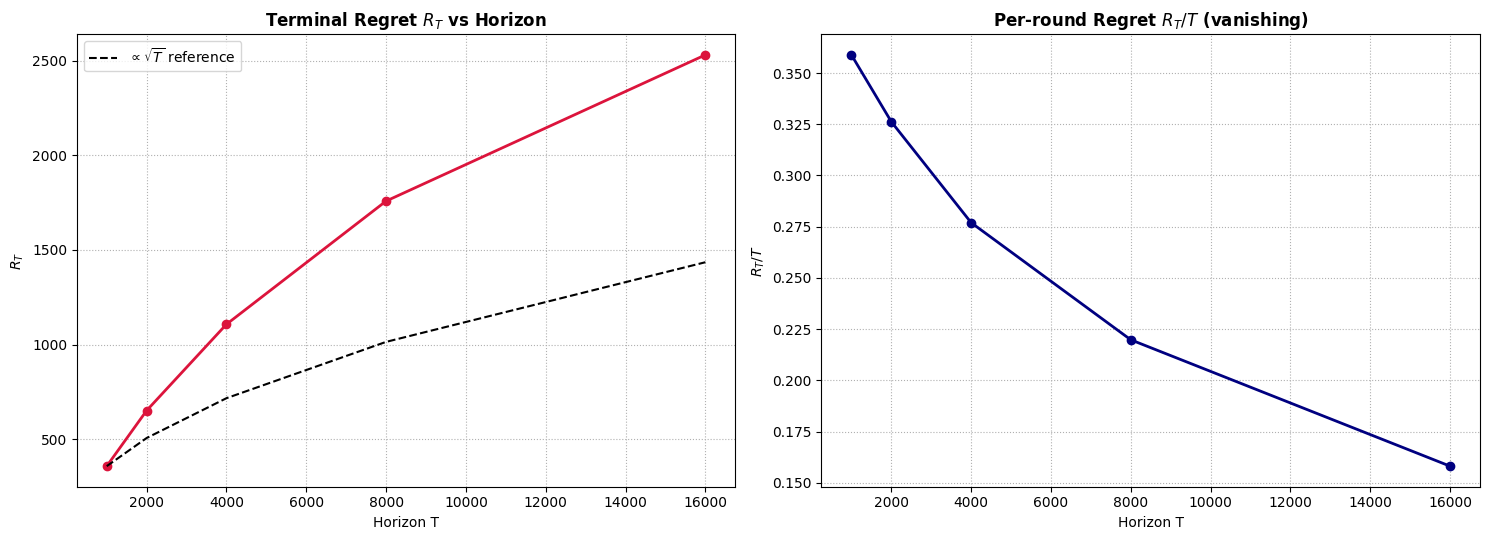

      T |        R_T |    R_T/T
   1000 |      358.9 |   0.3589
   2000 |      652.4 |   0.3262
   4000 |     1107.9 |   0.2770
   8000 |     1758.4 |   0.2198
  16000 |     2530.0 |   0.1581


In [ ]:
horizons = [1000, 2000, 4000, 8000, 16000]
N_SIM = 5
rows = []
for T in horizons:
    B = 0.5 * T; rho = B / T
    drift_schedule = make_linear_drift_schedule(T)
    finals = []
    for sim in range(N_SIM):
        r = run_primal_dual(T, B, drift_schedule, seed=3000 + sim)
        OPT_s, _, _, _ = claivoyant_opt(r['m_seq'], values, bid_space, rho)
        finals.append(T * OPT_s - r['util'].sum())
    rows.append((T, np.mean(finals), np.mean(finals) / T))

Ts = [r[0] for r in rows]
RT = [r[1] for r in rows]
RTpr = [r[2] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(Ts, RT, 'o-', color='crimson', lw=2)
axes[0].plot(Ts, [RT[0] * np.sqrt(T / Ts[0]) for T in Ts], 'k--', lw=1.5,
             label=r'$\propto\sqrt{T}$ reference')
axes[0].set_title('Terminal Regret $R_T$ vs Horizon', fontweight='bold')
axes[0].set_xlabel('Horizon T'); axes[0].set_ylabel(r'$R_T$')
axes[0].grid(True, linestyle=':'); axes[0].legend()

axes[1].plot(Ts, RTpr, 'o-', color='navy', lw=2)
axes[1].set_title('Per-round Regret $R_T/T$ (vanishing)', fontweight='bold')
axes[1].set_xlabel('Horizon T'); axes[1].set_ylabel(r'$R_T/T$')
axes[1].grid(True, linestyle=':')
plt.tight_layout(); plt.show()

print(f"{'T':>7} | {'R_T':>10} | {'R_T/T':>8}")
for T, rt, rtpr in rows:
    print(f"{T:>7} | {rt:>10.1f} | {rtpr:>8.4f}")


---
## Remarks

1. **Environment.** The market is *highly non-stationary*: the highest competing
   bid for every campaign is drawn from a Beta distribution whose mean drifts
   linearly with $t$ (from low to high competition over the horizon). There is
   no fixed distribution to estimate, so the stochastic UCB approach of
   Requirement 1 is inappropriate here.

2. **Algorithm (primal-dual, full feedback).** The primal side is one **Hedge**
   regret minimizer per campaign &mdash; the natural choice under full feedback, since
   observing $m_{t,i}$ for every auction lets us evaluate *all* arms each round (no
   exploration needed). The dual side is a single multiplier $\lambda_t$ that paces
   the shared budget via online gradient descent on the budget violation.

3. **Benchmark.** Against the *best fixed budget-feasible bidding policy in
   claivoyant* (an LP over per-campaign bid distributions sharing one budget), the
   cumulative regret is **sublinear**: $R_T/T \to 0$ (Part 6), roughly $\sqrt{T}$.

4. **Budget pacing works.** Across all runs the cumulative spend stays at or below
   $B$ (Parts 4&ndash;5), with **0 budget violations** observed. A binding budget keeps
   $\lambda_t$ persistently positive &mdash; the cost penalty in the primal Lagrangian
   bites &mdash; lowering spend and raising (but keeping sublinear) the regret. With a
   non-binding budget ($B=T$) the multiplier stays near $0$ and the agent behaves
   like an unconstrained Hedge bidder.

5. **Full feedback is essential.** Observing the highest competing bid of every
   auction (won or lost) is what makes Hedge applicable. The bandit-feedback case
   (only the won auctions revealed) would instead require an exploration-aware
   primal minimizer (e.g. EXP3-style), which is the subject of later requirements.
